In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy
import sunpy.map
import cv2
import random
from tqdm.notebook import tqdm
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
from astropy.time import Time
from astropy.visualization import ImageNormalize, AsinhStretch
from scipy.io import readsav
from copy import deepcopy
from sun_blinker import ImageBlinker, SunBlinker
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator
from sunpy.coordinates import propagate_with_solar_surface
from skimage.registration import phase_cross_correlation

In [2]:
hmi_supersynthia_file = "../../src/HMI/SuperSynthia/spDisambig_Br/hmi.SuperSynthIA.20221024_191200_TAI.Br.fits"
with fits.open(hmi_supersynthia_file) as hdul:
    hmi_ss_data = hdul[1].data.copy()
    hmi_ss_header = hdul[0].header.copy()
hmi_ss_header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
CHECKSUM= 'GqaDGoY9GoaCGoW9'   / HDU checksum updated 2024-08-29T00:44:57       
DATASUM = '         0'         / data unit checksum updated 2024-08-29T00:44:57 

In [3]:
hmi_m_720s_map = sunpy.map.Map('../../src/HMI/20221024/lvl1_720s/hmi.M_720s.20221024_191200_TAI.3.magnetogram.fits')
hmi_ss_map = sunpy.map.Map(hmi_ss_data, hmi_m_720s_map.wcs)
hmi_ss_map.plot_settings['cmap'] = "hmimag"
hmi_ss_map.plot_settings['norm'] = ImageNormalize(vmin=-1500, vmax=1500)

In [4]:
hmi_ss_map_rotated = hmi_ss_map.rotate()

In [5]:
with fits.open("../../src/SOTSP/20221024/lvl2/20221024_184138.fits") as hdul:
    sotsp_header = deepcopy(hdul[0].header)
    # for keys in hdul[1].header.keys():
    #     sotsp_header[keys] = hdul[1].header[keys]
    sotsp_header['CUNIT1'] = 'arcsec'
    sotsp_header['CUNIT2'] = 'arcsec'
    sotsp_header['CTYPE1'] = 'HPLN-TAN'
    sotsp_header['CTYPE2'] = 'HPLT-TAN'
    sotsp_header['CRVAL1'] = sotsp_header['XCEN']
    sotsp_header['CRVAL2'] = sotsp_header['YCEN']
    sotsp_header['CDELT1'] = 0.297 #from Fouhey et al. 2023
    sotsp_header['CDELT2'] = 0.320
    sotsp_header['NAXIS'] = 2
    # sotsp_header['RSUN_REF'] = sotsp_header['SOLAR_RA']
    # sotsp_header['DATE-OBS'] = sotsp_header['TSTART']
    # sotsp_header["DATE-END"] = sotsp_header['TEND']
    sotsp_header["DATE-AVG"] = (Time(sotsp_header["TSTART"]) + \
                                (Time(sotsp_header["TEND"]) - Time(sotsp_header["TSTART"]))/2).strftime("%Y-%m-%dT%H:%M:%S")
    
# with fits.open("../../src/SOTSP/20221024/lvl2/sotsp_l2_20221024_190447_3643101203_20221024_184138_magfield_index.fits") as hdul:
#     lsmal_header = deepcopy(hdul[0].header)
#     sotsp_header["PC1_1"] = lsmal_header["PC1_1"]
#     sotsp_header["PC1_2"] = lsmal_header["PC1_2"]
#     sotsp_header["PC2_1"] = lsmal_header["PC2_1"]
#     sotsp_header["PC2_2"] = lsmal_header["PC2_2"]

sotsp_corr_file = readsav("../../src/SOTSP/20221024/lvl2/20221024_184138/sotsp_lvl2_missing_col_corrected.sav")


In [6]:
sotsp_corr_file.keys()

dict_keys(['data_new', 'slitmap', 'scan_info', 'index', 'data', 'phead'])

In [7]:
sotsp_corr_file['data_new'].shape

(42, 512, 1000)

In [8]:
Time(sotsp_corr_file['phead'].tstart[0])

<Time object: scale='utc' format='isot' value=2022-10-24T18:41:38.918>

In [9]:
sotsp_corr_file['index'][0].dtype.names

('SIMPLE',
 'BITPIX',
 'NAXIS',
 'NAXIS1',
 'NAXIS2',
 'EXTEND',
 'XCEN',
 'YCEN',
 'XSCALE',
 'YSCALE',
 'TSTART',
 'TEND',
 'MAPID',
 'LMIN1',
 'LMAX1',
 'LMIN2',
 'LMAX2',
 'INVCODE',
 'INVVERS',
 'L2RTIME',
 'MERLIN_D$I',
 'MERMAXCO',
 'MERMAXDM',
 'MERMINDM',
 'MERMAXFA',
 'MERMAXIT',
 'MERMINPO',
 'MERSLM',
 'MERSFLD',
 'MERSPSI',
 'MERSAZM',
 'MERSETAO',
 'MERDOPP',
 'MERDMP',
 'MERSBZER',
 'MERSB1MU',
 'MERVMAC',
 'MERSALPH',
 'MERSDELT',
 'MERSCEN1',
 'MERSCEN2',
 'P_ANGLE',
 'B_ANGLE',
 'SOLAR_RA',
 'COMMENT',
 'HISTORY',
 'FITSTAGS',
 'CUNIT1',
 'CUNIT2',
 'FTYPE',
 'INSTRUME',
 'TELESCOP',
 'CDELT1',
 'CDELT2',
 'CROTA1',
 'CROTA2',
 'DATE_OBS',
 'DATE_END',
 'BUNIT',
 'DISAMBIG',
 'DAMBALGO',
 'DAMBVERS',
 'AMBGFLG',
 'AMBPFLG',
 'AMBNPAD',
 'AMBNAP',
 'AMBNTX',
 'AMBNTY',
 'AMBATHR',
 'AMBBTHR',
 'AMBNEROD',
 'AMBNGROW',
 'AMBSEED',
 'AMBNEQ',
 'AMBLMBDA',
 'AMBTFCT0',
 'AMBTFCTR',
 'AMBERAT')

In [10]:
for ii, index_ in enumerate(sotsp_corr_file['index']):
    print(ii, index_.ftype)

0 b'Magnetic Field Strength'
1 b'Magnetic Field Inclination'
2 b'Magnetic Field Azimuth'
3 b'Doppler Shift of 630.15nm'
4 b'Doppler Shift of 630.25nm'
5 b'Doppler Width'
6 b'Line Strength'
7 b'Damping Parameter'
8 b'Source Function'
9 b'Source Function Gradient'
10 b'Macroturbulence'
11 b'Stray Light Fraction'
12 b'Stray Light Shift'
13 b'Magnetic Field Error'
14 b'Magnetic Field Inclination Error'
15 b'Magnetic Field Azimuth Error'
16 b'Doppler Shift of 630.15nm Error'
17 b'Doppler Shift of 630.25nm Error'
18 b'Doppler Width Error'
19 b'Line Strength Error'
20 b'Damping Parameter Error'
21 b'Source Function Error'
22 b'Source Function Gradient Error'
23 b'Macroturbulence Error'
24 b'Stray Light Fraction Error'
25 b'Stray Light Shift Error'
26 b'Chi-Squared for Stokes I'
27 b'Chi-Squared for Stokes Q'
28 b'Chi-Squared for Stokes U'
29 b'Chi-Squared for Stokes V'
30 b'Total Chi-Squared [I, Q, U & V]'
31 b'Continuum Intensity'
32 b'Polarization Degree'
33 b'Magnitude of Stokes V'
34 b'Fi

In [11]:
sotsp_map_x = sotsp_corr_file['data_new'][36,:,:].copy()
sotsp_map_y = sotsp_corr_file['data_new'][37,:,:].copy()
bad_x = np.unique(np.where(sotsp_map_x == 0)[1])

sotsp_cdelt1_aver = np.nanmean(np.diff(sotsp_map_x, axis=1))
sotsp_cdelt2_aver = np.nanmean(np.diff(sotsp_map_y, axis=0))
sotsp_cdelt1_aver, sotsp_cdelt2_aver

sotsp_br_data = sotsp_corr_file['data_new'][40,:,:].copy()
sotsp_bt_data = sotsp_corr_file['data_new'][39,:,:].copy()
sotsp_bp_data = sotsp_corr_file['data_new'][38,:,:].copy()
# sotsp_map_x[sotsp_map_x == 0] = np.nan
# sotsp_map_y[sotsp_map_y == 0] = np.nan

In [12]:
sotsp_br_data.shape

(512, 1000)

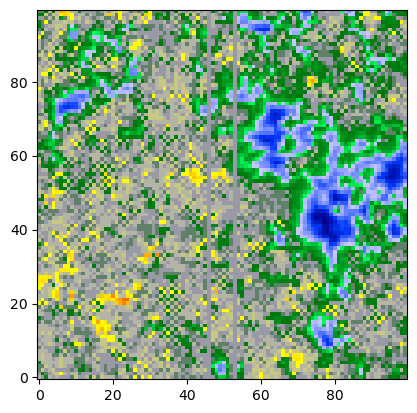

In [13]:
plt.imshow(sotsp_br_data[250:350,450:550], cmap="hmimag", vmin=-1500, vmax=1500, origin='lower')

In [14]:
sotsp_map_x_cleaned = np.delete(sotsp_map_x, bad_x, axis=1)
sotsp_map_y_cleaned = np.delete(sotsp_map_y, bad_x, axis=1)
sotsp_br_data_cleaned = np.delete(sotsp_br_data, bad_x, axis=1)
sotsp_bt_data_cleaned = np.delete(sotsp_bt_data, bad_x, axis=1)
sotsp_bp_data_cleaned = np.delete(sotsp_bp_data, bad_x, axis=1)

In [15]:
sotsp_map_x_max = np.nanmax(sotsp_map_x_cleaned)
sotsp_map_x_min = np.nanmin(sotsp_map_x_cleaned)
sotsp_map_y_max = np.nanmax(sotsp_map_y_cleaned)
sotsp_map_y_min = np.nanmin(sotsp_map_y_cleaned)

x_interp = np.linspace(sotsp_map_x_min, sotsp_map_x_max,
                       np.ceil((sotsp_map_x_max - sotsp_map_x_min) / sotsp_cdelt1_aver).astype(int))
y_interp = np.linspace(sotsp_map_y_min, sotsp_map_y_max,
                        np.ceil((sotsp_map_y_max - sotsp_map_y_min) / sotsp_cdelt2_aver).astype(int))

xi_interp = np.moveaxis(np.array(np.meshgrid(x_interp, y_interp)), 0, -1)

In [16]:
xy_flatten = (sotsp_map_x_cleaned.flatten(), sotsp_map_y_cleaned.flatten())
# data_interp_func = LinearNDInterpolator(xy_flatten, sotsp_br_data_cleaned.flatten(), fill_value=np.nan)
data_interp_func = CloughTocher2DInterpolator(xy_flatten, sotsp_br_data_cleaned.flatten(), fill_value=np.nan)
sotsp_br_interp = data_interp_func(xi_interp)

data_interp_func = CloughTocher2DInterpolator(xy_flatten, sotsp_bt_data_cleaned.flatten(), fill_value=np.nan)
sotsp_bt_interp = data_interp_func(xi_interp)

data_interp_func = CloughTocher2DInterpolator(xy_flatten, sotsp_bp_data_cleaned.flatten(), fill_value=np.nan)
sotsp_bp_interp = data_interp_func(xi_interp)

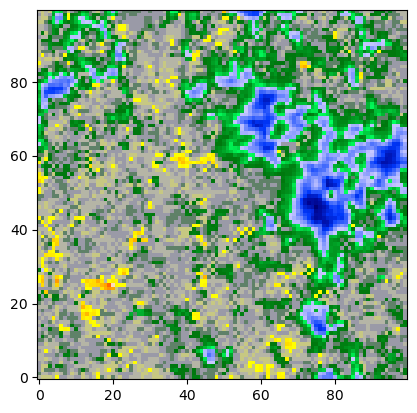

In [17]:
plt.imshow(sotsp_br_interp[250:350,450:550], cmap="hmimag", vmin=-1500, vmax=1500, origin='lower')

In [18]:
def xy_to_wcs(x,y,date_obs,rsun=696000000.*u.m):
    nx = len(x)
    ny = len(y)
    wcs_header = sunpy.map.make_fitswcs_header(
        (nx, ny),
        coordinate=SkyCoord(x[nx//2], y[ny//2], frame='helioprojective',
                            obstime=date_obs, rsun=rsun, unit=u.arcsec),
        reference_pixel=[nx//2, ny//2]*u.pix,
        scale=[np.nanmean(np.diff(x)), np.nanmean(np.diff(y))]*u.arcsec/u.pix,
        telescope=sotsp_corr_file['index'][0].telescop,
        instrument=sotsp_corr_file['index'][0].instrume,
    )

    return wcs_header

In [19]:
sotsp_interp_wcs = xy_to_wcs(x_interp, y_interp, Time(sotsp_corr_file['phead'].tstart[0]),)

In [20]:
sotsp_br_map = sunpy.map.Map(sotsp_br_interp, sotsp_interp_wcs)
sotsp_br_map.plot_settings['cmap'] = "hmimag"
sotsp_br_map.plot_settings['norm'] = plt.Normalize(-1500, 1500)
sotsp_br_map.plot_settings['aspect'] = sotsp_br_map.scale.axis2/sotsp_br_map.scale.axis1

In [21]:
sotsp_bp_map = sunpy.map.Map(sotsp_bp_interp, sotsp_interp_wcs)
sotsp_bp_map.plot_settings['cmap'] = "hmimag"
sotsp_bp_map.plot_settings['norm'] = plt.Normalize(-1500, 1500)
sotsp_bp_map.plot_settings['aspect'] = sotsp_br_map.scale.axis2/sotsp_br_map.scale.axis1
sotsp_bt_map = sunpy.map.Map(sotsp_bt_interp, sotsp_interp_wcs)
sotsp_bt_map.plot_settings['cmap'] = "hmimag"
sotsp_bt_map.plot_settings['norm'] = plt.Normalize(-1500, 1500)
sotsp_bt_map.plot_settings['aspect'] = sotsp_br_map.scale.axis2/sotsp_br_map.scale.axis1

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs,dsun_obs
 [sunpy.map.mapbase]


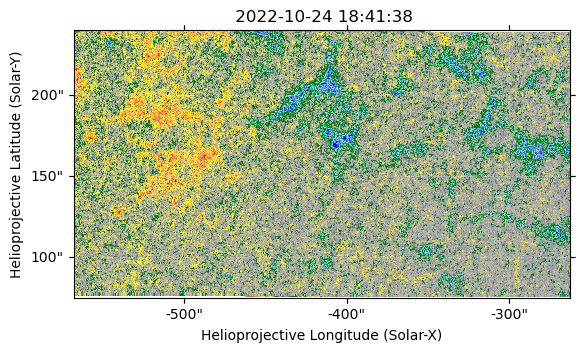

In [22]:
sotsp_br_map.plot()

In [23]:
with propagate_with_solar_surface():
    SunBlinker(sotsp_br_map, hmi_ss_map, reproject=True,)

In [24]:
with propagate_with_solar_surface():
    hmi_ss_to_sotsp_map = hmi_ss_map.reproject_to(sotsp_br_map.wcs)


In [25]:
def calc_shift(map_ref, map_move):
    shift, error, diffphase = phase_cross_correlation(map_ref.data, map_move.data, upsample_factor=10,
                                                      reference_mask=~np.isnan(map_ref.data),
                                                      moving_mask=~np.isnan(map_move.data),)
    ref_coord = map_ref.wcs.pixel_to_world(0,0)
    move_coord = map_move.wcs.pixel_to_world(shift[1], shift[0])

    shift_x = move_coord.Tx - ref_coord.Tx
    shift_y = move_coord.Ty - ref_coord.Ty

    return shift_x, shift_y

In [26]:
shift_x_sotsp, shift_y_sotsp = calc_shift(hmi_ss_to_sotsp_map, sotsp_br_map)

In [27]:
sotsp_br_map_shifted = sotsp_br_map.shift_reference_coord(shift_x_sotsp, shift_y_sotsp)
sotsp_bt_map_shifted = sotsp_bt_map.shift_reference_coord(shift_x_sotsp, shift_y_sotsp)
sotsp_bp_map_shifted = sotsp_bp_map.shift_reference_coord(shift_x_sotsp, shift_y_sotsp)

In [28]:
with propagate_with_solar_surface():
    SunBlinker(sotsp_br_map_shifted, hmi_ss_map, reproject=True,)

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs,dsun_obs
 [sunpy.map.mapbase]


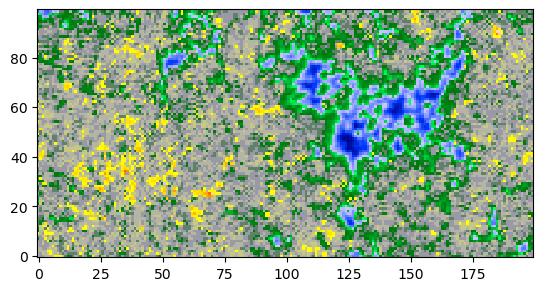

In [29]:
plt.imshow(sotsp_br_map_shifted.data[250:350, 400:600], cmap="hmimag", norm=plt.Normalize(-1500, 1500), origin="lower",
           interpolation="none")

In [30]:
with propagate_with_solar_surface():
    hmi_ss_to_sotsp_map_shifted = hmi_ss_map.reproject_to(sotsp_br_map_shifted.wcs)

In [31]:
hmi_img = hmi_ss_to_sotsp_map_shifted.data
# hmi_img = cv2.resize(hmi_img, (hmi_img.shape[1], hmi_img.shape[0]), interpolation=cv2.INTER_LINEAR)
hmi_img = cv2.normalize(hmi_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sotsp_img = sotsp_br_map_shifted.data
sotsp_img = cv2.normalize(sotsp_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

/tmp/ipykernel_48007/3797929314.py:5: RuntimeWarning: invalid value encountered in cast
  sotsp_img = cv2.normalize(sotsp_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


In [32]:
sift = cv2.SIFT_create()
kp_hmi, des_hmi = sift.detectAndCompute(hmi_img, None)
kp_sotsp, des_sotsp = sift.detectAndCompute(sotsp_img, None)

In [33]:
hmi_img_kp = cv2.drawKeypoints(hmi_img, kp_hmi, 0, (0, 0, 255), 
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS) 
sotsp_img_kp = cv2.drawKeypoints(sotsp_img, kp_sotsp, 0, (0, 0, 255),
                                    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

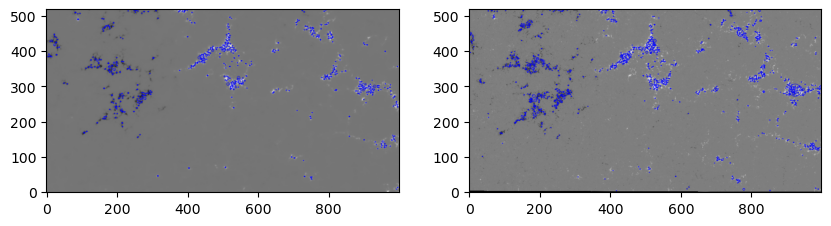

In [34]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.imshow(hmi_img_kp, origin="lower")
ax2.imshow(sotsp_img_kp, origin="lower")

In [35]:
def matcher(des1, des2,threshold=1):
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 200)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1,des2,k=2)

    # Apply ratio test
    good = []
    for m,n in matches:
        if m.distance < threshold*n.distance:
            good.append(m)

    return good

In [36]:
hmi_sot_good_matches = matcher(des_sotsp, des_hmi, 0.7)

In [37]:
def homography(kp1, kp2, matches):
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()
    # h,w = img1.shape
    # pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    # dst = cv2.perspectiveTransform(pts,M)
    # img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)

    return M, matchesMask

In [38]:
hmi_sot_matrix, hmi_sot_matchesmask = homography(kp_sotsp, kp_hmi, hmi_sot_good_matches)

In [39]:
match_draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = hmi_sot_matchesmask, # draw only inliers
                   flags = 2)
hmi_sot_matches_img = cv2.drawMatches(sotsp_img,kp_sotsp,hmi_img,kp_hmi,hmi_sot_good_matches,None,**match_draw_params)

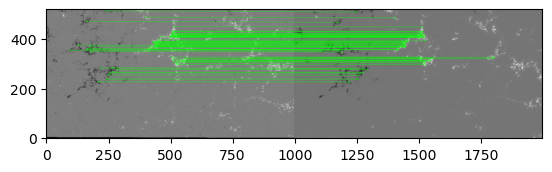

In [40]:
plt.imshow(hmi_sot_matches_img,origin="lower")

In [41]:
sotsp_img_warp = cv2.warpPerspective(sotsp_img,hmi_sot_matrix, dsize=(hmi_img.shape[1],hmi_img.shape[0]),
                                     borderMode=cv2.BORDER_CONSTANT, borderValue=np.nan)

In [42]:
ImageBlinker(sotsp_img_warp[200:400,450:650], hmi_img[200:400,450:650], save_fname='../../figs/test_figs/sot_hmi.gif', fps=0.5)

In [51]:
sotsp_br_img_warp = cv2.warpPerspective(sotsp_br_map_shifted.data,hmi_sot_matrix, dsize=(hmi_img.shape[1],hmi_img.shape[0]),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=np.nan, flags=cv2.INTER_CUBIC)
sotsp_br_warp_map = sunpy.map.Map(sotsp_br_img_warp, hmi_ss_to_sotsp_map_shifted.wcs)
sotsp_br_warp_map.meta["instrume"] = "SOT/SP"
sotsp_br_warp_map.meta["rsun_ref"] = 696000000.
sotsp_br_warp_map.meta["telescop"] = "HINODE"
sotsp_br_warp_map.meta["data_lev"] = 2
sotsp_br_warp_map.meta["comment"] = "SOT/SP Level 2 Br magnetogram warped to HMI LOS magnetogram using SIFT and RANSAC"
sotsp_br_warp_map = sunpy.map.Map(sotsp_br_warp_map.data, sotsp_br_warp_map.meta)

In [52]:
sotsp_bt_img_warp = cv2.warpPerspective(sotsp_bt_map_shifted.data,hmi_sot_matrix, dsize=(hmi_img.shape[1],hmi_img.shape[0]),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=np.nan, flags=cv2.INTER_CUBIC)
sotsp_bt_warp_map = sunpy.map.Map(sotsp_bt_img_warp, hmi_ss_to_sotsp_map_shifted.wcs)
sotsp_bt_warp_map.meta["instrume"] = "SOT/SP"
sotsp_bt_warp_map.meta["rsun_ref"] = 696000000.
sotsp_bt_warp_map.meta["telescop"] = "HINODE"
sotsp_bt_warp_map.meta["data_lev"] = 2
sotsp_bt_warp_map.meta["comment"] = "SOT/SP Level 2 Bt magnetogram warped to HMI LOS magnetogram using SIFT and RANSAC"
sotsp_bt_warp_map = sunpy.map.Map(sotsp_bt_warp_map.data, sotsp_bt_warp_map.meta)

sotsp_bp_img_warp = cv2.warpPerspective(sotsp_bp_map_shifted.data,hmi_sot_matrix, dsize=(hmi_img.shape[1],hmi_img.shape[0]),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=np.nan, flags=cv2.INTER_CUBIC)
sotsp_bp_warp_map = sunpy.map.Map(sotsp_bp_img_warp, hmi_ss_to_sotsp_map_shifted.wcs)
sotsp_bp_warp_map.meta["instrume"] = "SOT/SP"
sotsp_bp_warp_map.meta["rsun_ref"] = 696000000.
sotsp_bp_warp_map.meta["telescop"] = "HINODE"
sotsp_bp_warp_map.meta["data_lev"] = 2
sotsp_bp_warp_map.meta["comment"] = "SOT/SP Level 2 Bp magnetogram warped to HMI LOS magnetogram using SIFT and RANSAC"
sotsp_bp_warp_map = sunpy.map.Map(sotsp_bp_warp_map.data, sotsp_bp_warp_map.meta)

In [53]:
def crop_to_drop_boundary(map):
    data = map.data
    nan_mask = np.isnan(data)
    nan_mask_col = np.all(nan_mask, axis=0)
    nan_mask_row = np.all(nan_mask, axis=1)
    bottom_left = [nan_mask_col.argmin(), nan_mask_row.argmin()]*u.pix
    top_right = [nan_mask_col.size - nan_mask_col[::-1].argmin(), nan_mask_row.size - nan_mask_row[::-1].argmin()]*u.pix

    map_crop = map.submap(bottom_left, top_right=top_right)
    
    return map_crop

In [54]:
sotsp_br_warp_map = crop_to_drop_boundary(sotsp_br_warp_map)
sotsp_bt_warp_map = crop_to_drop_boundary(sotsp_bt_warp_map)
sotsp_bp_warp_map = crop_to_drop_boundary(sotsp_bp_warp_map)

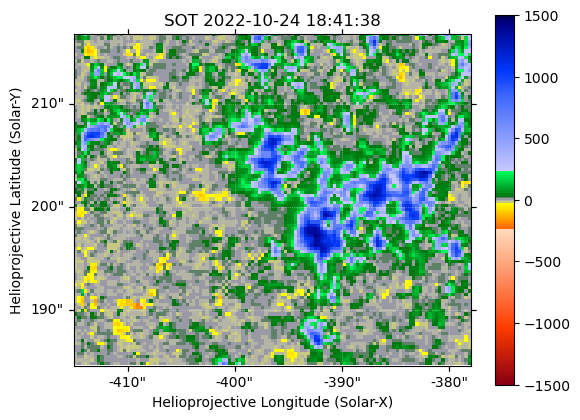

In [55]:
sotsp_br_warp_map.submap((430,250)*u.pix,top_right=(550,350)*u.pix).plot(cmap="hmimag", norm=plt.Normalize(-1500, 1500),)
plt.colorbar()

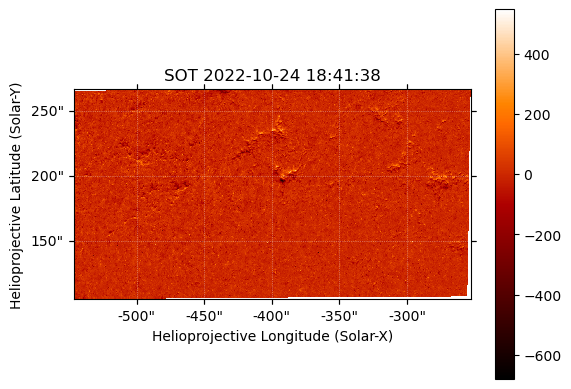

In [56]:
sotsp_bt_warp_map.plot()
plt.colorbar()

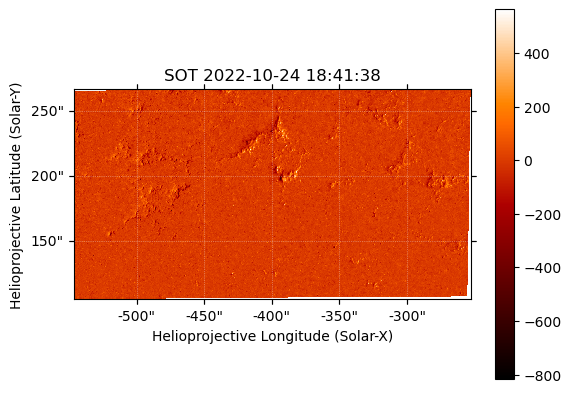

In [57]:
sotsp_bp_warp_map.plot()
plt.colorbar()

In [58]:
sotsp_br_warp_map.save("../../src/coalign_map/20221024/sotsp_br_warp_to_hmi.fits", overwrite=True)
sotsp_bt_warp_map.save("../../src/coalign_map/20221024/sotsp_bt_warp_to_hmi.fits", overwrite=True)
sotsp_bp_warp_map.save("../../src/coalign_map/20221024/sotsp_bp_warp_to_hmi.fits", overwrite=True)

 [astropy.io.fits.verify]
